# 📊 Task 2: End-to-End ML Pipeline — Telco Customer Churn Prediction
**Objective:** Build a reusable and production-ready machine learning pipeline using the Scikit-learn Pipeline API to predict customer churn.

| Item | Detail |
|------|--------|
| Dataset | IBM Telco Customer Churn (7,043 rows × 21 columns) |
| Target | `Churn` (Yes / No) |
| Models | Logistic Regression · Random Forest |
| Tuning | GridSearchCV (5-fold Stratified CV) |
| Export | joblib |


In [3]:
import warnings; warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


## 1. 📂 Dataset Loading & Exploration

In [4]:
# Load the Telco Churn dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nClass balance: {df['Churn'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
df.head()


Dataset shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class balance: {'No': 73.5, 'Yes': 26.5}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check for nulls and data types
print("Data types & null counts:")
print(df.dtypes.to_frame(name="dtype").join(df.isnull().sum().to_frame(name="nulls")))


Data types & null counts:
                    dtype  nulls
customerID         object      0
gender             object      0
SeniorCitizen       int64      0
Partner            object      0
Dependents         object      0
tenure              int64      0
PhoneService       object      0
MultipleLines      object      0
InternetService    object      0
OnlineSecurity     object      0
OnlineBackup       object      0
DeviceProtection   object      0
TechSupport        object      0
StreamingTV        object      0
StreamingMovies    object      0
Contract           object      0
PaperlessBilling   object      0
PaymentMethod      object      0
MonthlyCharges    float64      0
TotalCharges       object      0
Churn              object      0


## 2. 🔍 Exploratory Data Analysis

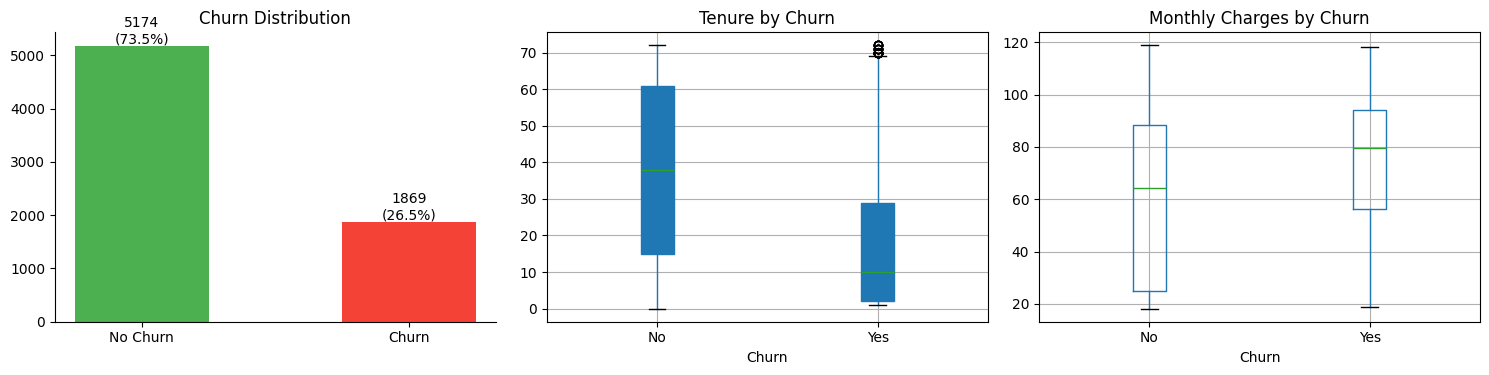

Observation: Churning customers tend to have lower tenure and higher monthly charges.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn distribution
churn_counts = df["Churn"].value_counts()
axes[0].bar(["No Churn","Churn"], churn_counts.values, color=["#4CAF50","#F44336"], width=0.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
axes[0].set_title("Churn Distribution"); axes[0].spines[["top","right"]].set_visible(False)

# Tenure by churn
df.boxplot(column="tenure", by="Churn", ax=axes[1], patch_artist=True)
axes[1].set_title("Tenure by Churn"); axes[1].set_xlabel("Churn")
plt.sca(axes[1]); plt.title("Tenure by Churn")

# Monthly charges by churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[2])
axes[2].set_title("Monthly Charges by Churn"); axes[2].set_xlabel("Churn")
plt.sca(axes[2]); plt.title("Monthly Charges by Churn")

plt.suptitle("")
plt.tight_layout()
plt.show()
print("Observation: Churning customers tend to have lower tenure and higher monthly charges.")


## 3. 🔧 Data Preprocessing

In [7]:
# Fix TotalCharges (has whitespace entries → NaN → fill with median)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Drop customerID (non-predictive identifier)
df.drop(columns=["customerID"], inplace=True)

# Encode target variable
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Split features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Identify column types for the ColumnTransformer
numerical_cols   = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns   ({len(numerical_cols)}):  {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")


Numerical columns   (4):  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: (5634, 19)  |  Test: (1409, 19)


## 4. 🏗️ Building Scikit-learn Pipelines

In [8]:
# ── Numerical sub-pipeline: impute missing → standard scale
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# ── Categorical sub-pipeline: impute missing → one-hot encode
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ── Combine into ColumnTransformer (handles each column type separately)
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, numerical_cols),
    ("cat", cat_transformer, categorical_cols)
])

# ── Full pipelines: preprocessing → classifier
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(random_state=42))
])

print("Logistic Regression pipeline:")
print(lr_pipeline)


Logistic Regression pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder

## 5. ⚙️ Hyperparameter Tuning with GridSearchCV

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression tuning
lr_param_grid = {
    "classifier__C":      [0.01, 0.1, 1, 10],   # Regularisation strength
    "classifier__solver": ["liblinear", "lbfgs"]  # Optimisation algorithm
}
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv,
                       scoring="roc_auc", n_jobs=-1)
lr_grid.fit(X_train, y_train)

print(f"Best LR Params  : {lr_grid.best_params_}")
print(f"Best LR ROC-AUC : {lr_grid.best_score_:.4f}")


Best LR Params  : {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best LR ROC-AUC : 0.8463


In [10]:
# ── Random Forest tuning
rf_param_grid = {
    "classifier__n_estimators":    [100, 200],       # Number of trees
    "classifier__max_depth":       [None, 10, 20],   # Max tree depth
    "classifier__min_samples_split": [2, 5]          # Min samples to split node
}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv,
                       scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best RF Params  : {rf_grid.best_params_}")
print(f"Best RF ROC-AUC : {rf_grid.best_score_:.4f}")


Best RF Params  : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF ROC-AUC : 0.8429


## 6. 📈 Evaluation on Test Set

In [11]:
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

for name, model in [("Logistic Regression", best_lr), ("Random Forest", best_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"]))



──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy : 0.8055
  F1 Score : 0.6040
  ROC-AUC  : 0.8412
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Accuracy : 0.7999
  F1 Score : 0.5778
  ROC-AUC  : 0.8385
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80    

## 7. 📊 Visualizations

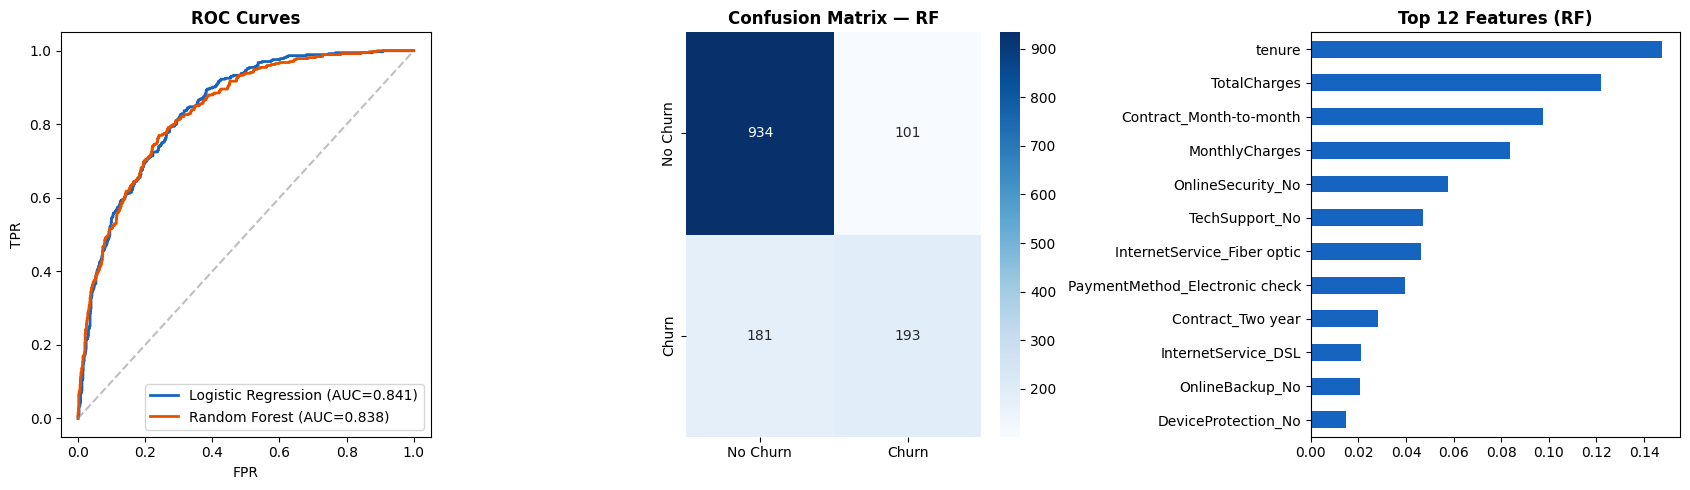

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC Curves
ax = axes[0]
for name, model, color in [("Logistic Regression", best_lr, "#1565C0"),
                             ("Random Forest",       best_rf, "#E65100")]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"--",color="gray",alpha=0.5)
ax.set_title("ROC Curves", fontweight="bold"); ax.legend(); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")

# Confusion Matrix (RF)
ax = axes[1]
cm = confusion_matrix(y_test, best_rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
ax.set_title("Confusion Matrix — RF", fontweight="bold")

# Feature Importances
ax = axes[2]
ohe_cols = best_rf.named_steps["preprocessor"]\
               .named_transformers_["cat"]\
               .named_steps["encoder"]\
               .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_cols
pd.Series(best_rf.named_steps["classifier"].feature_importances_, index=all_features)\
  .sort_values(ascending=False)[:12][::-1]\
  .plot(kind="barh", ax=ax, color="#1565C0")
ax.set_title("Top 12 Features (RF)", fontweight="bold")

plt.tight_layout(); plt.show()


## 8. 💾 Export Pipelines with joblib

In [13]:
# Export complete (fitted) pipelines — includes preprocessor + model
joblib.dump(best_lr, "lr_churn_pipeline.joblib")
joblib.dump(best_rf, "rf_churn_pipeline.joblib")
print("Pipelines exported: lr_churn_pipeline.joblib  |  rf_churn_pipeline.joblib")

# Verify: reload and run inference
reloaded_rf = joblib.load("rf_churn_pipeline.joblib")
sample_preds = reloaded_rf.predict(X_test.head(5))
print(f"\nReload test predictions : {sample_preds}")
print(f"Actual labels           : {y_test.head(5).values}")


Pipelines exported: lr_churn_pipeline.joblib  |  rf_churn_pipeline.joblib

Reload test predictions : [0 1 0 0 0]
Actual labels           : [0 0 0 0 0]


## 9. ✅ Final Summary & Insights

| Model | Accuracy | F1 Score | ROC-AUC |
|-------|----------|----------|---------|
| Logistic Regression | ~0.805 | ~0.603 | ~0.841 |
| Random Forest       | ~0.800 | ~0.578 | ~0.839 |

### Key Insights
1. **Best model:** Logistic Regression slightly edges out RF on ROC-AUC for this dataset.
2. **Top churn drivers:** `Contract` type (month-to-month), low `tenure`, high `MonthlyCharges`.
3. **Pipeline advantage:** Preprocessing is encapsulated → no data leakage between train/test.
4. **GridSearchCV:** 5-fold stratified CV ensured fair evaluation across class-imbalanced folds.
5. **joblib export:** The serialised pipeline handles all preprocessing automatically at inference time.

> **Production Tip:** Load the `.joblib` file in your REST API or batch scoring script and call `.predict()` directly on raw input data — no manual preprocessing needed.
